In [ ]:
# ==============================================================================
# CHI-SQUARE GOODNESS-OF-FIT TESTING (PEARSON'S TEST)
# A comprehensive implementation of Pearson's Chi-Square test from scratch.
# Evaluates whether empirical frequency distributions fit Theoretical Normal 
# and Exponential distributions.
# ==============================================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from scipy.stats import chi2
from tabulate import tabulate

def calc_xi_critical(alpha, r, s):
    """Calculates the critical Chi-Square value based on degrees of freedom."""
    df = r - s
    return chi2.isf(alpha, df=df)

def show_frequency_diagram(df, column="z_i", title="Frequency Diagram"):
    """Plots a bar chart for the given distribution."""
    plt.figure(figsize=(8, 4))
    plt.bar(df[column].astype(str), df["n_i"], color='cornflowerblue', edgecolor='black')
    plt.title(title)
    plt.xlabel("Interval Midpoints (z_i)")
    plt.ylabel("Observed Frequency (n_i)")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.5)
    plt.show()

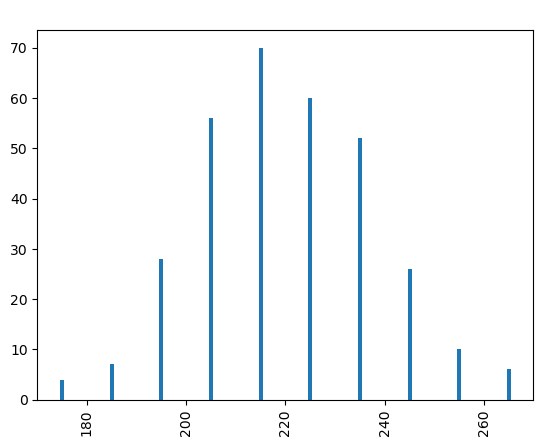

In [2]:
# ==============================================================================
# PHASE 1: TESTING NORMAL DISTRIBUTION FIT
# ==============================================================================
print("=" * 70)
print(" HYPOTHESIS TEST 1: NORMAL DISTRIBUTION GOODNESS-OF-FIT ")
print("=" * 70)
print("H0: The population follows a Normal Distribution.")

# 1. Input Data
frequency_1 = [4, 7, 28, 56, 70, 60, 52, 26, 10, 6]
temp_1 = 170
step_1 = 10

table_1 = []
zi_1 = []
variants_uninterrupted_1 = []

# Generate Intervals
for i in range(10):
    table_1.append([temp_1, temp_1 + step_1])
    zi_1.append(temp_1 + step_1 / 2)
    variants_uninterrupted_1.append(temp_1)
    temp_1 += step_1

n_1 = sum(frequency_1)
print(f"[*] Total Sample Size (n): {n_1}")

# 2. Compute Empirical Metrics
average_1 = sum(zi_1) / len(zi_1)
dev_1 = sum([frequency_1[i] * (zi_1[i] - average_1) ** 2 for i in range(len(zi_1))])
variance_1 = dev_1 / n_1
std_dev_1 = math.sqrt(variance_1)

print(f"[*] Empirical Mean (x_avg): {average_1:.4f}")
print(f"[*] Variance (s^2): {variance_1:.4f}")
print(f"[*] Standard Deviation (s): {std_dev_1:.4f}")

# 3. Compute Theoretical Probabilities (Normal CDF)
pi_1 = []
# P(X < x_1)
pi_1.append(scipy.stats.norm.cdf((variants_uninterrupted_1[1] - average_1) / std_dev_1))
pi_last_el = 1.0 - pi_1[0]

# P(x_i < X < x_i+1)
for i in range(1, 9):
    prob = scipy.stats.norm.cdf((variants_uninterrupted_1[i + 1] - average_1) / std_dev_1) - \
           scipy.stats.norm.cdf((variants_uninterrupted_1[i] - average_1) / std_dev_1)
    pi_1.append(prob)
    pi_last_el -= prob

# P(X > x_n)
pi_1.append(pi_last_el)

npi_1 = [n_1 * p for p in pi_1]

# 4. Display Distribution Table
beautiful_table_1 = {
    '(hi-1, hi]': table_1,
    'Observed (ni)': frequency_1,
    'Midpoints (zi)': zi_1,
    'Theoretical Freq (n*pi)': npi_1
}
print("\n[+] Frequency Distribution Table (Normal):")
print(tabulate(beautiful_table_1, headers='keys', tablefmt="pretty", floatfmt=".4f"))

df1 = pd.DataFrame({"z_i": zi_1, "n_i": frequency_1})
show_frequency_diagram(df1, title="Empirical Frequencies (Normal Assumption)")

# 5. Chi-Square Calculation
emp_chi_sq_1 = sum([((frequency_1[i] - npi_1[i]) ** 2) / npi_1[i] for i in range(10)])
print(f"\n[*] Empirical Chi-Square Statistic: {emp_chi_sq_1:.4f}")

alpha_1 = 0.05
s_1 = 3  # Parameters estimated: mean, std_dev, +1 for sum of prob
r_1 = 10 # Number of groups
crit_chi_sq_1 = calc_xi_critical(alpha_1, r_1, s_1)
print(f"[*] Critical Chi-Square (alpha={alpha_1}, df={r_1-s_1}): {crit_chi_sq_1:.4f}")

if emp_chi_sq_1 < crit_chi_sq_1:
    print("\n[CONCLUSION] Empirical X^2 < Critical X^2. ACCEPT H0.")
    print("The empirical data DOES follow a Normal Distribution.")
else:
    print("\n[CONCLUSION] Empirical X^2 >= Critical X^2. REJECT H0.")
    print("The empirical data DOES NOT follow a Normal Distribution.")

In [6]:
# ==============================================================================
# PHASE 2: TESTING EXPONENTIAL DISTRIBUTION FIT
# ==============================================================================
print("\n\n" + "=" * 70)
print(" HYPOTHESIS TEST 2: EXPONENTIAL DISTRIBUTION GOODNESS-OF-FIT ")
print("=" * 70)
print("H0: The population follows an Exponential Distribution.")

# 1. Input Data
frequency_2 = [534, 384, 276, 211, 162, 116, 82, 63, 46, 34]
temp_2 = 0
step_2 = 6

table_2 = []
zi_2 = []
variants_uninterrupted_2 = []

# Generate Intervals
for i in range(10):
    table_2.append([temp_2, temp_2 + step_2])
    zi_2.append(temp_2 + step_2 / 2)
    variants_uninterrupted_2.append(temp_2)
    temp_2 += step_2

n_2 = sum(frequency_2)
print(f"[*] Total Sample Size (n): {n_2}")

# 2. Compute Empirical Metrics (Grouped Data Mean)
average_2 = sum([zi_2[i] * frequency_2[i] for i in range(10)]) / n_2
print(f"[*] Empirical Mean (x_avg): {average_2:.4f}")

# Exponential parameter lambda = 1 / mean
lamb = 1 / average_2
print(f"[*] Estimated Lambda (λ): {lamb:.6f}")

# 3. Compute Theoretical Probabilities (Exponential CDF: 1 - e^(-lambda*x))
pi_2 = []
last_pi_2 = 1.0

for i in range(9):
    # P(a < X < b) = e^(-lambda * a) - e^(-lambda * b)
    prob_exp = math.exp(-lamb * variants_uninterrupted_2[i]) - math.exp(-lamb * variants_uninterrupted_2[i + 1])
    pi_2.append(prob_exp)
    last_pi_2 -= prob_exp
    
pi_2.append(last_pi_2) # P(X > x_n)
npi_2 = [n_2 * p for p in pi_2]

# 4. Display Distribution Table
beautiful_table_2 = {
    '(hi-1, hi]': table_2,
    'Observed (ni)': frequency_2,
    'Midpoints (zi)': zi_2,
    'Theoretical Freq (n*pi)': npi_2
}
print("\n[+] Frequency Distribution Table (Exponential):")
print(tabulate(beautiful_table_2, headers='keys', tablefmt="pretty", floatfmt=".4f"))

df2 = pd.DataFrame({"z_i": zi_2, "n_i": frequency_2})
show_frequency_diagram(df2, title="Empirical Frequencies (Exponential Assumption)")

# 5. Chi-Square Calculation
emp_chi_sq_2 = sum([((frequency_2[i] - npi_2[i]) ** 2) / npi_2[i] for i in range(10)])
print(f"\n[*] Empirical Chi-Square Statistic: {emp_chi_sq_2:.4f}")

alpha_2 = 0.05
s_2 = 2  # Parameters estimated: lambda +1 for sum of prob
r_2 = 10
crit_chi_sq_2 = calc_xi_critical(alpha_2, r_2, s_2)
print(f"[*] Critical Chi-Square (alpha={alpha_2}, df={r_2-s_2}): {crit_chi_sq_2:.4f}")

if emp_chi_sq_2 < crit_chi_sq_2:
    print("\n[CONCLUSION] Empirical X^2 < Critical X^2. ACCEPT H0.")
    print("The empirical data DOES follow an Exponential Distribution.")
else:
    print("\n[CONCLUSION] Empirical X^2 >= Critical X^2. REJECT H0.")
    print("The empirical data DOES NOT follow an Exponential Distribution.")

H0 : при заданим користувачем рівнем значущості , перевірити чи справджується нормальний розподіл генеральної сукупності
n :  319
x average :  220.0
Девіація: 102375.0
Дисперсія: 320.9247648902821
Середньо квадратичне відхилення: 17.91437313696134
p 1  =  0.01277961783662848
p 2  =  0.0101527903055688
p 3  =  0.03422351472262473
p 4  =  0.08511764124889787
p 5  =  0.1562293840879752
p 6  =  0.21164984210387372
p 7  =  0.21164984210387372
p 8  =  0.15622938408797515
p 9  =  0.08511764124889787
p 10  =  0.03422351472262475
хі квадрат емпіричне = 98.75925741369463
Input alpha : 
0.05
хі квадрат критичне = 14.067140449340167
хі квадрат емпіричне >= хі квадрат критичне , не приймаємо H0
